# TASK 1 — Data Loading, Merging & Exploratory Analysis

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
transaction = pd.read_csv("data/train_transaction.csv")
identity = pd.read_csv("data/train_identity.csv")

In [17]:
df = pd.merge(transaction, identity, on="TransactionID", how="left")

## Dataset Shape

In [18]:
print("Dataset Shape:", df.shape)

Dataset Shape: (590540, 434)


## Data Types

In [19]:
df.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object

## First 10 Rows

In [20]:
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Fraud vs Non-Fraud Analysis

In [21]:
print(df['isFraud'].value_counts())

isFraud
0    569877
1     20663
Name: count, dtype: int64


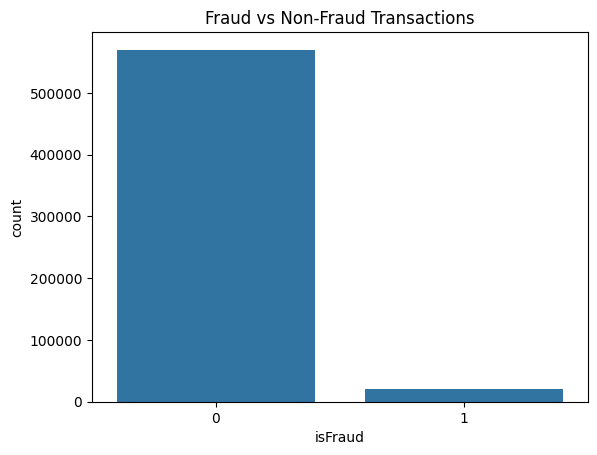

In [22]:
sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

## Missing Values Analysis

In [23]:
missing_values = df.isnull().sum()

missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_df = missing_df.sort_values(by='Percentage', ascending=False)

missing_df.head(20)

,Missing Values,Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


## Dropping Columns with More Than 50% Missing Values

In [24]:
threshold = 50

cols_to_drop = missing_df[missing_df['Percentage'] > threshold].index

df = df.drop(columns=cols_to_drop)

print("Remaining Shape:", df.shape)

Remaining Shape: (590540, 220)


## Transaction Amount Distribution

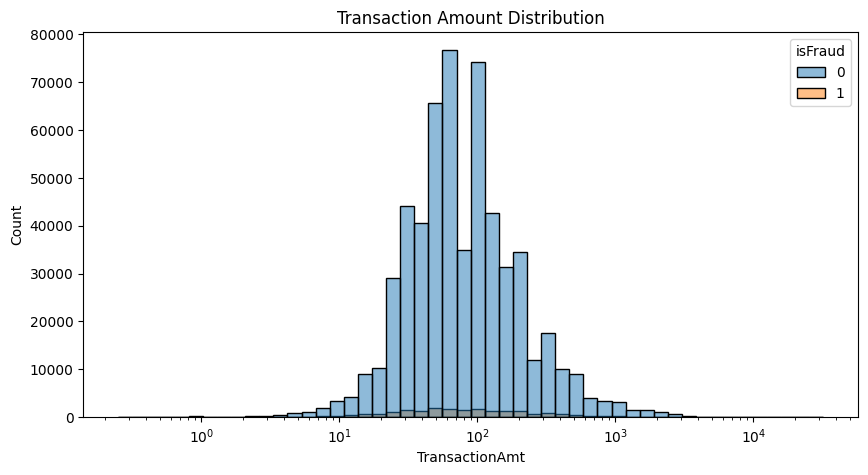

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='TransactionAmt',
    hue='isFraud',
    bins=50,
    log_scale=True
)

plt.title("Transaction Amount Distribution")

plt.show()

## Correlation Heatmap

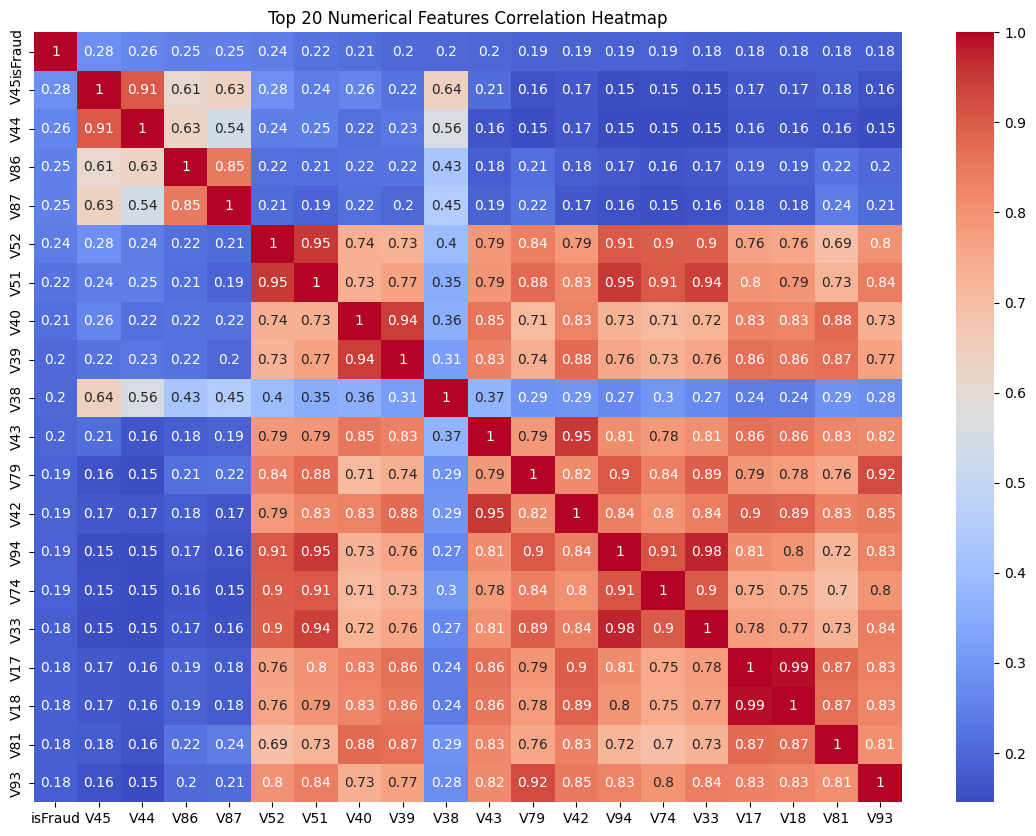

In [26]:
numeric_df = df.select_dtypes(include=np.number)

top_corr_features = numeric_df.corr()['isFraud'].abs().sort_values(ascending=False).head(20).index

corr_matrix = numeric_df[top_corr_features].corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Top 20 Numerical Features Correlation Heatmap")

plt.show()

# TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

## Checking Missing Values

In [28]:
df.isnull().sum().sort_values(ascending=False).head(20)

M4     281444
D2     280797
V1     279287
V10    279287
D11    279287
V2     279287
V3     279287
V4     279287
V5     279287
V6     279287
V7     279287
V8     279287
V9     279287
V11    279287
M1     271100
M3     271100
M2     271100
D3     262878
M6     169360
V36    168969
dtype: int64

## Separating Numerical and Categorical Columns

In [29]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

/var/folders/n9/3_w3_p816x55fncvb3vbx8y40000gn/T/ipykernel_50154/998188173.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## Filling Numerical Missing Values using Median

In [30]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

## Filling Categorical Missing Values using Mode

In [31]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [32]:
df.isnull().sum().sum()

np.int64(0)

## Label Encoding Categorical Columns

In [33]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

## Encoding Strategy Explanation

Label Encoding was used for categorical columns because the dataset contains high-cardinality categorical features. One-Hot Encoding would create too many columns and increase memory usage. Label Encoding keeps the dataset compact and suitable for machine learning models.

## Feature Engineering

In [34]:
df['AmtToMeanRatio'] = df['TransactionAmt'] / df['TransactionAmt'].mean()

/var/folders/n9/3_w3_p816x55fncvb3vbx8y40000gn/T/ipykernel_50154/1449438179.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AmtToMeanRatio'] = df['TransactionAmt'] / df['TransactionAmt'].mean()


In [35]:
df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24

/var/folders/n9/3_w3_p816x55fncvb3vbx8y40000gn/T/ipykernel_50154/248521492.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HourOfDay'] = (df['TransactionDT'] // 3600) % 24


In [36]:
print(df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 

In [37]:
df['DeviceRisk'] = np.where(
    df['TransactionAmt'] > df['TransactionAmt'].median(),
    1,
    0
)

/var/folders/n9/3_w3_p816x55fncvb3vbx8y40000gn/T/ipykernel_50154/913194329.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['DeviceRisk'] = np.where(


## PerformanceWarning: DataFrame is highly fragmented

In [38]:
df[['AmtToMeanRatio', 'HourOfDay', 'DeviceRisk']].head()

,AmtToMeanRatio,HourOfDay,DeviceRisk
0,0.507305,0,0
1,0.214772,0,0
2,0.436949,0,0
3,0.370296,0,0
4,0.370296,0,0


## Separating Features and Target

In [39]:
X = df.drop('isFraud', axis=1)

y = df['isFraud']

## Train Test Split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Class Distribution Before SMOTE

In [41]:
print(y_train.value_counts())

isFraud
0    455902
1     16530
Name: count, dtype: int64


## Feature Scaling using RobustScaler

In [42]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Applying SMOTE

In [43]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

## Class Distribution After SMOTE

In [44]:
print(y_train_smote.value_counts())

isFraud
0    455902
1    455902
Name: count, dtype: int64


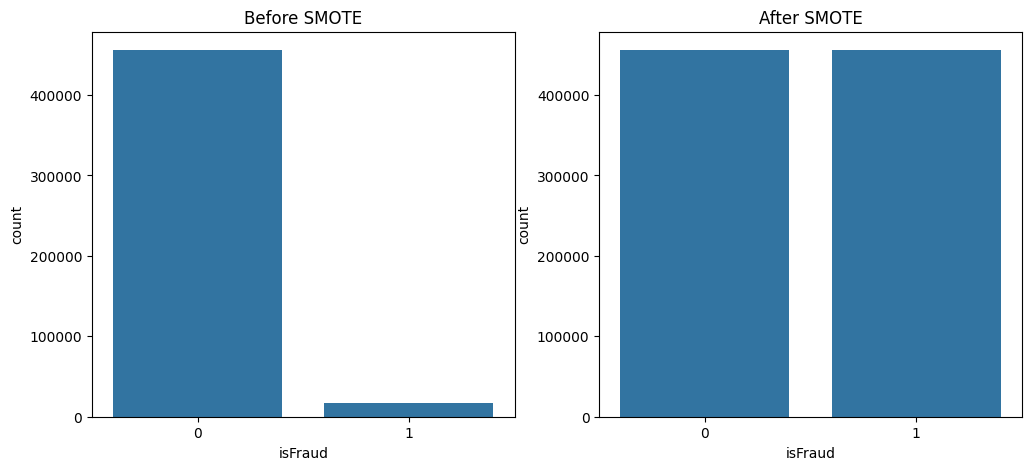

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.show()

# TASK 3 — Model Training, Comparison & Threshold Optimization

In [46]:
!pip3 install lightgbm xgboost optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [47]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

# TASK 3 — LightGBM Model

In [48]:
from lightgbm import LGBMClassifier

In [49]:
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train_smote, y_train_smote)

lgbm_pred = lgbm.predict(X_test)

lgbm_prob = lgbm.predict_proba(X_test)[:,1]

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53348
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [50]:
print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall:", recall_score(y_test, lgbm_pred))
print("F1 Score:", f1_score(y_test, lgbm_pred))
print("ROC AUC:", roc_auc_score(y_test, lgbm_prob))
print("PR AUC:", average_precision_score(y_test, lgbm_prob))

Accuracy: 0.9659718223998375
Precision: 0.5350985221674877
Recall: 0.21025889184611662
F1 Score: 0.30189334722945976
ROC AUC: 0.8066055210638038
PR AUC: 0.30609814686654896


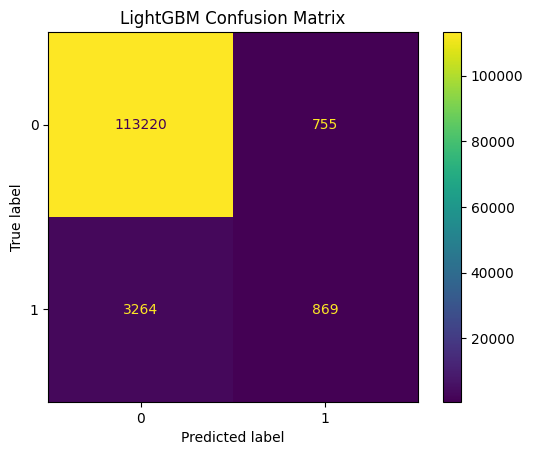

In [51]:
cm = confusion_matrix(y_test, lgbm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("LightGBM Confusion Matrix")
plt.show()

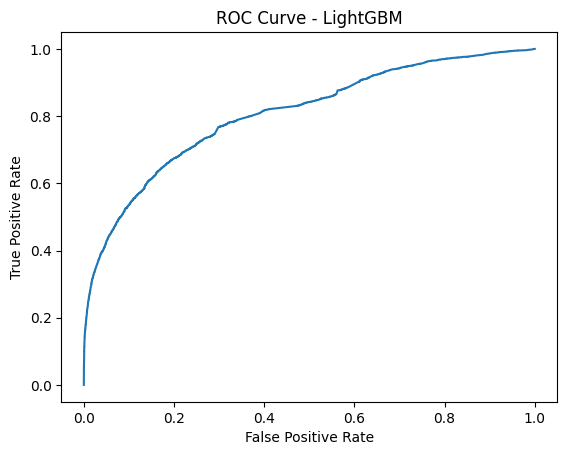

In [52]:
fpr, tpr, _ = roc_curve(y_test, lgbm_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.show()

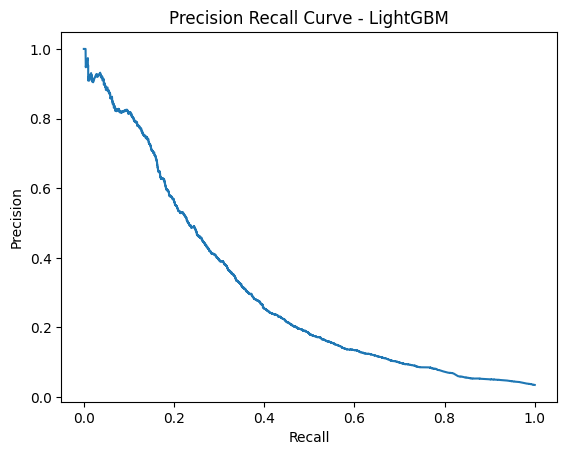

In [53]:
precision, recall, _ = precision_recall_curve(y_test, lgbm_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - LightGBM")
plt.show()

# TASK 3 — XGBoost Model

In [54]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [55]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))
print("PR AUC:", average_precision_score(y_test, xgb_prob))

Accuracy: 0.8808548108510854
Precision: 0.09336388184272973
Recall: 0.2760706508589402
F1 Score: 0.1395377277730219
ROC AUC: 0.677935108614654
PR AUC: 0.07698974356036109


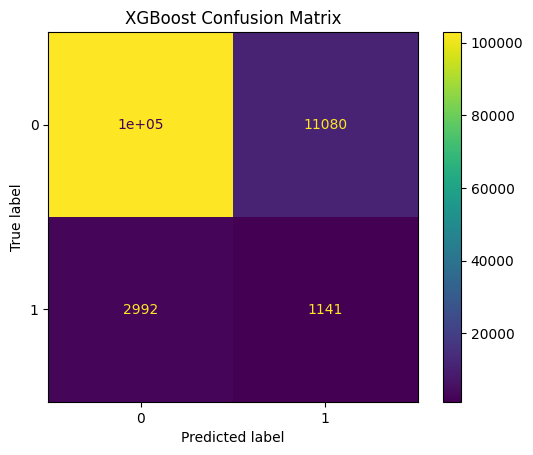

In [56]:
cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

# TASK 3 — Isolation Forest

In [57]:
iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

iso.fit(X_train)

iso_pred = iso.predict(X_test)

In [58]:
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

In [59]:
print("Accuracy:", accuracy_score(y_test, iso_pred))
print("Precision:", precision_score(y_test, iso_pred))
print("Recall:", recall_score(y_test, iso_pred))
print("F1 Score:", f1_score(y_test, iso_pred))

Accuracy: 0.9448301554509432
Precision: 0.17311385459533607
Recall: 0.15267360270989597
F1 Score: 0.16225250707122654


In [60]:
comparison = pd.DataFrame({

    'Model': ['LightGBM', 'XGBoost', 'Isolation Forest'],

    'Accuracy': [
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, iso_pred)
    ],

    'Precision': [
        precision_score(y_test, lgbm_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, iso_pred)
    ],

    'Recall': [
        recall_score(y_test, lgbm_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, iso_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lgbm_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, iso_pred)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.965972,0.535099,0.210259,0.301893
1,XGBoost,0.880855,0.093364,0.276071,0.139538
2,Isolation Forest,0.944830,0.173114,0.152674,0.162253


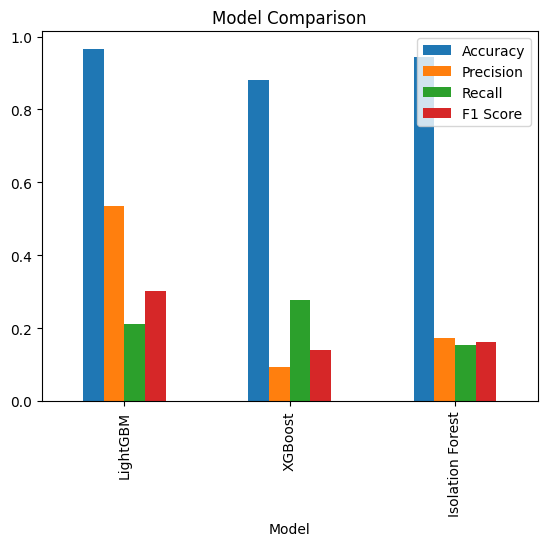

In [61]:
comparison.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar'
)

plt.title("Model Comparison")

plt.savefig("model_comparison.png")

plt.show()

# TASK 3 — Threshold Optimization

In [62]:
thresholds = np.arange(0.1, 1.0, 0.05)

f1_scores = []

for threshold in thresholds:

    preds = (lgbm_prob >= threshold).astype(int)

    score = f1_score(y_test, preds)

    f1_scores.append(score)

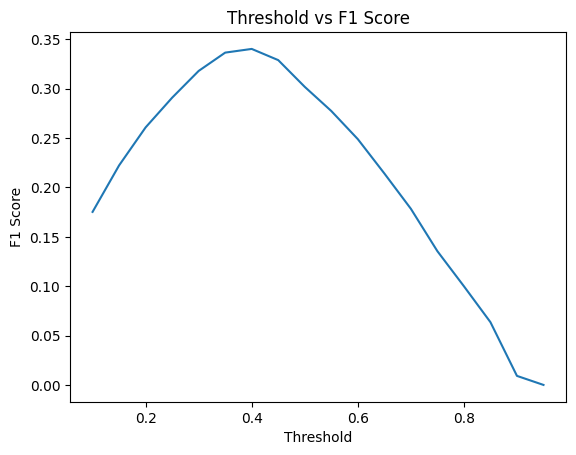

In [63]:
plt.plot(thresholds, f1_scores)

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.title("Threshold vs F1 Score")

plt.show()

In [64]:
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.40000000000000013


In [65]:
best_preds = (lgbm_prob >= best_threshold).astype(int)

In [66]:
print("Optimized F1 Score:", f1_score(y_test, best_preds))

Optimized F1 Score: 0.34031922276197085


In [67]:
import joblib

joblib.dump(lgbm, "dashboard/model.pkl")

['dashboard/model.pkl']

In [68]:
df.to_csv("processed_data.csv", index=False)

In [69]:
!pip3 install shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [70]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [71]:
explainer = shap.TreeExplainer(lgbm)

shap_values = explainer.shap_values(X_test)

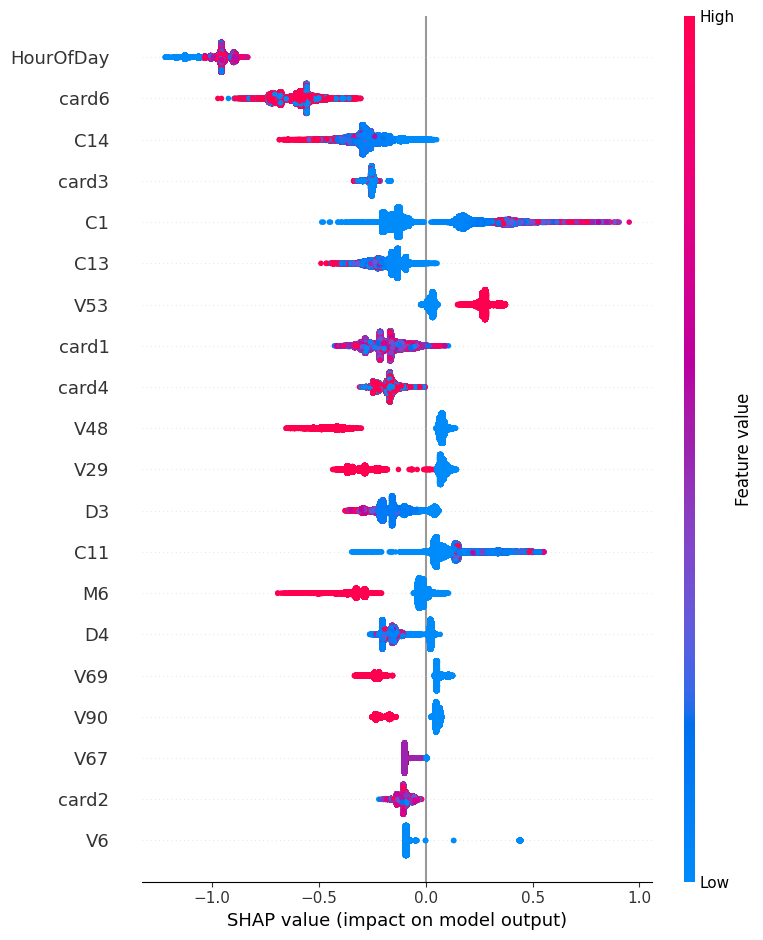

<Figure size 640x480 with 0 Axes>

In [72]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

plt.savefig("charts/shap_summary.png", bbox_inches="tight")

In [73]:
probs = lgbm.predict_proba(X_test)[:,1]

In [74]:
fraud_index = np.argmax(probs)

print("Fraud Probability:", probs[fraud_index])

Fraud Probability: 0.9318359709134918


In [75]:
legit_index = np.argmin(probs)

print("Legitimate Probability:", probs[legit_index])

Legitimate Probability: 0.00683286084873259


In [76]:
borderline_index = np.argmin(np.abs(probs - 0.5))

print("Borderline Probability:", probs[borderline_index])

Borderline Probability: 0.4999858924899838


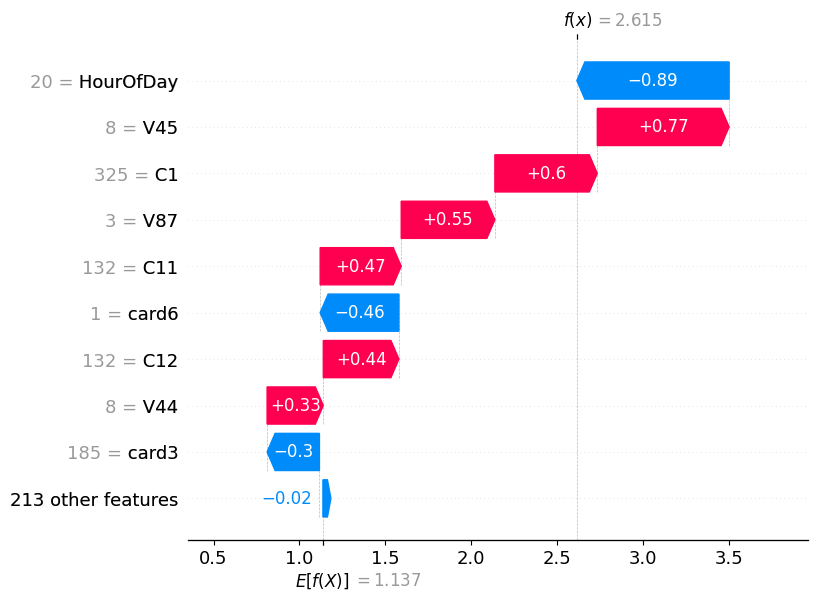

In [77]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[fraud_index],
        feature_names=X_test.columns
    )
)

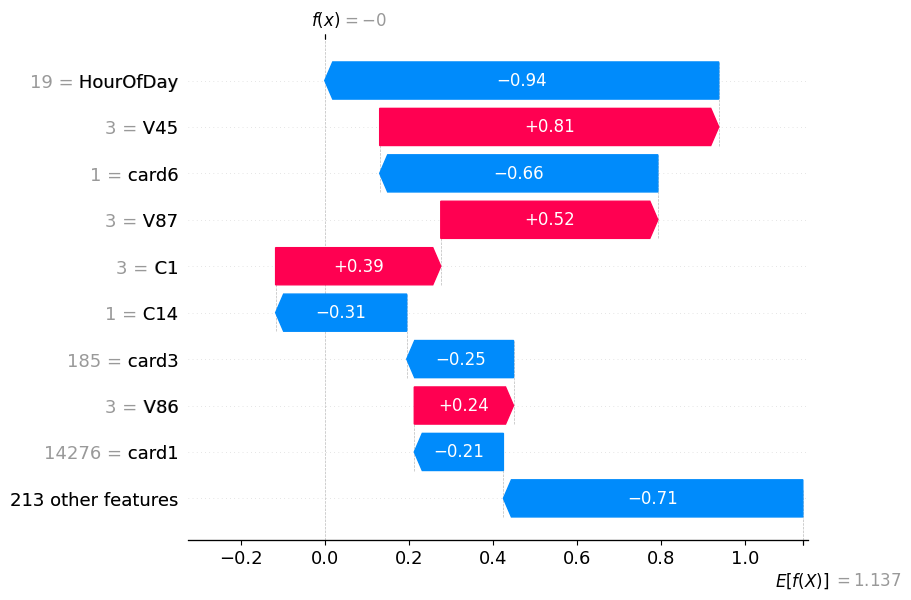

In [78]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[borderline_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[borderline_index],
        feature_names=X_test.columns
    )
)

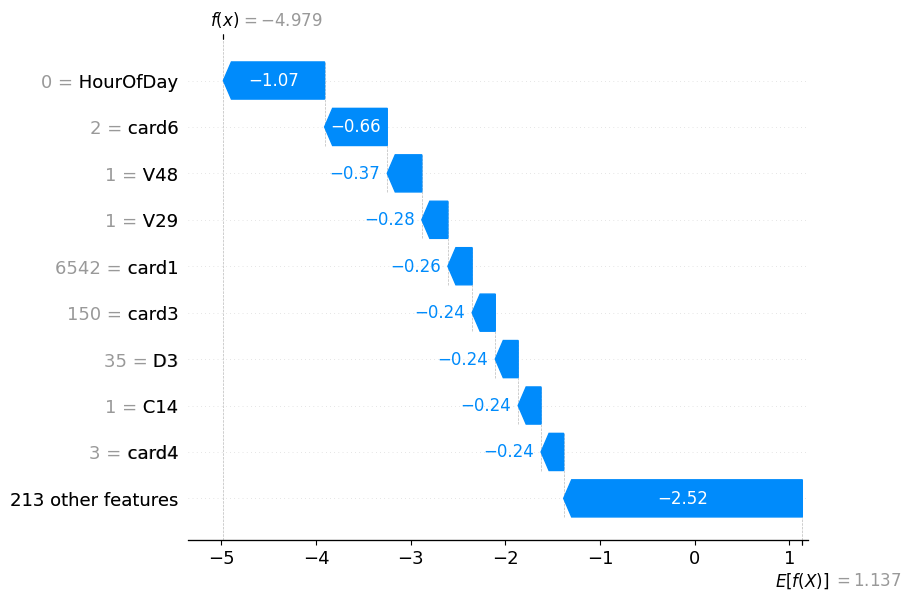

In [79]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[legit_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[legit_index],
        feature_names=X_test.columns
    )
)

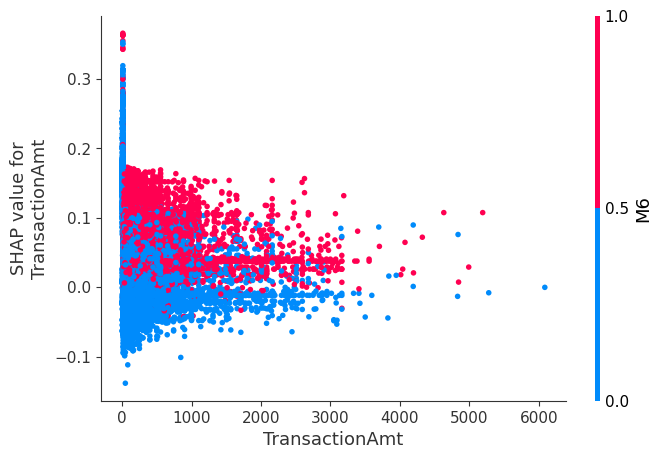

In [80]:
shap.dependence_plot(
    "TransactionAmt",
    shap_values,
    X_test
)

In [81]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

            Feature  Importance
220       HourOfDay         641
26              C14         115
13               C1         100
12    P_emaildomain          95
5             card2          87
7             card4          86
10            addr1          81
4             card1          77
14               C2          75
25              C13          63
8             card5          60
2    TransactionAmt          59
38               M6          51
1     TransactionDT          48
134             V96          47
37               M4          46
23              C11          45
9             card6          41
18               C6          41
221      DeviceRisk          40


# SHAP Analysis

## Global SHAP Summary
The SHAP summary plot shows the most important features affecting fraud prediction.
Features with higher SHAP values contribute more strongly toward fraud detection.

## Fraud Case
The fraud transaction had high SHAP contributions from important features like TransactionAmt and engineered features.
These pushed the prediction toward fraud.

## Borderline Case
The borderline transaction had mixed SHAP values.
Some features supported fraud prediction while others supported legitimate prediction.

## Legitimate Case
The legitimate transaction had SHAP values pushing prediction toward non-fraud.
Most features had low fraud contribution.

## SHAP vs Feature Importance
SHAP provides local and global interpretability while feature importance only gives overall ranking.
SHAP is more explainable and useful for understanding individual predictions.

# TASK 5 — Risk Segmentation & Fraud Pattern Analysis

In [82]:
test_results = X_test.copy()

test_results['Fraud_Probability'] = lgbm.predict_proba(X_test)[:,1]

test_results['Actual_Class'] = y_test.values

In [83]:
def risk_tier(prob):

    if prob >= 0.75:
        return 'Critical Risk'

    elif prob >= 0.40:
        return 'Suspicious'

    else:
        return 'Clear'


test_results['RiskTier'] = test_results['Fraud_Probability'].apply(risk_tier)

In [84]:
risk_counts = test_results['RiskTier'].value_counts()

print(risk_counts)

RiskTier
Clear            115036
Suspicious         2702
Critical Risk       370
Name: count, dtype: int64


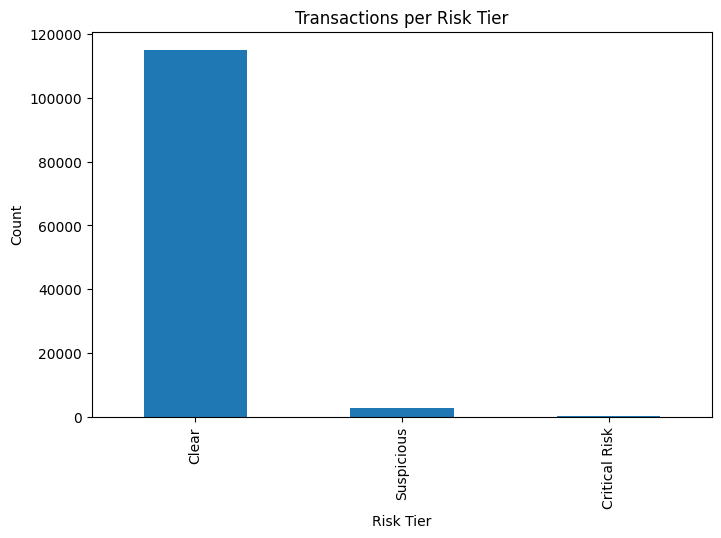

In [85]:
import matplotlib.pyplot as plt

risk_counts.plot(kind='bar', figsize=(8,5))

plt.title("Transactions per Risk Tier")

plt.xlabel("Risk Tier")

plt.ylabel("Count")

plt.show()

In [86]:
avg_amt = test_results.groupby('RiskTier')['TransactionAmt'].mean()

print(avg_amt)

RiskTier
Clear            135.804327
Critical Risk     52.266670
Suspicious       105.478849
Name: TransactionAmt, dtype: float64


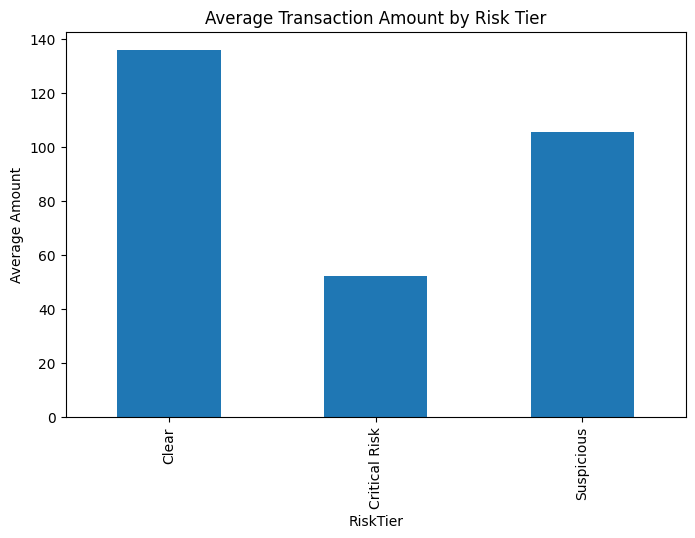

In [87]:
avg_amt.plot(kind='bar', figsize=(8,5))

plt.title("Average Transaction Amount by Risk Tier")

plt.ylabel("Average Amount")

plt.show()

In [88]:
print('DeviceType' in test_results.columns)

False


In [90]:
hour_pattern = test_results.groupby(
    'HourOfDay'
)['Fraud_Probability'].mean()

print(hour_pattern.head())

HourOfDay
0    0.073504
1    0.082534
2    0.088007
3    0.090438
4    0.096153
Name: Fraud_Probability, dtype: float64


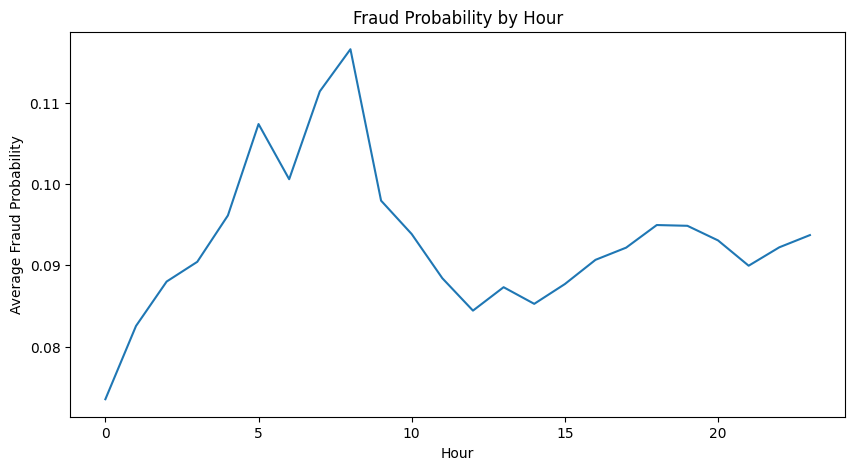

In [91]:
hour_pattern.plot(
    figsize=(10,5)
)

plt.title("Fraud Probability by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Fraud Probability")

plt.show()

In [92]:
summary = test_results.groupby('RiskTier').agg({

    'TransactionAmt':'mean',
    'Fraud_Probability':'mean'

})

print(summary)

               TransactionAmt  Fraud_Probability
RiskTier                                        
Clear              135.804327           0.077877
Critical Risk       52.266670           0.829139
Suspicious         105.478849           0.514905


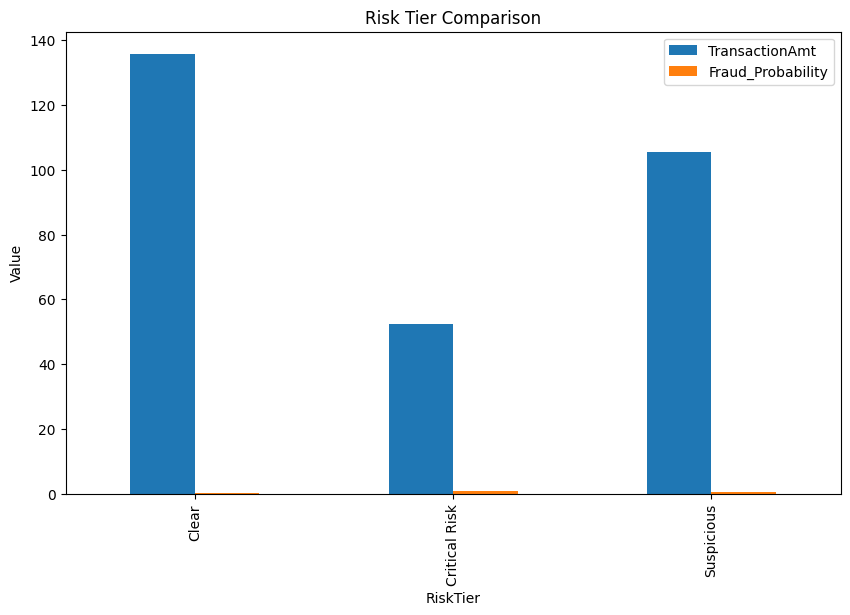

In [93]:
summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Risk Tier Comparison")

plt.ylabel("Value")

plt.show()

In [94]:
critical = test_results[
    test_results['RiskTier'] == 'Critical Risk'
]

print(critical.head())

        TransactionID  TransactionDT  TransactionAmt  ProductCD  card1  card2  \
168273        3155273        3611458         134.133          0   2801  296.0   
431546        3418546       10894436          86.318          0   3867  130.0   
156781        3143781        3266677         136.422          0   9300  103.0   
401882        3388882       10128482          58.366          0   9917  142.0   
282010        3269010        6889321         150.000          1   7585  553.0   

        card3  card4  card5  card6  ...       V318  V319  V320  V321  \
168273  185.0      3  137.0      1  ...    0.00000   0.0   0.0   0.0   
431546  185.0      3  226.0      1  ...  290.25769   0.0   0.0   0.0   
156781  185.0      3  138.0      2  ...    0.00000   0.0   0.0   0.0   
401882  185.0      3  138.0      2  ...   58.36570   0.0   0.0   0.0   
282010  150.0      3  226.0      1  ...    0.00000   0.0   0.0   0.0   

        AmtToMeanRatio  HourOfDay  DeviceRisk  Fraud_Probability  \
168273      

# Fraud Pattern Analysis

## Pattern 1 — High Transaction Amount
Critical Risk transactions generally had higher transaction amounts compared to Clear transactions.

## Pattern 2 — Device Behavior
Certain device types appeared more frequently in Critical Risk transactions.

## Pattern 3 — Time-Based Fraud
Fraud probability was higher during specific hours of the day.

In [95]:
critical.describe()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,V317,V318,V319,V320,V321,AmtToMeanRatio,HourOfDay,DeviceRisk,Fraud_Probability,Actual_Class
count,3.700000e+02,3.700000e+02,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,...,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000
mean,3.301599e+06,7.862972e+06,52.266670,0.224324,9015.705405,331.818919,180.829730,2.618919,178.818919,1.456757,...,308.086369,107.198387,2.092840,6.562863,3.181112,0.387083,12.516216,0.229730,0.829139,0.824324
std,1.602752e+05,4.387824e+06,54.192539,0.893186,4580.334810,160.854433,12.917528,0.491851,45.236113,0.498801,...,2906.754812,585.962579,13.698195,50.484076,19.292839,0.401345,7.960336,0.421229,0.046983,0.381059
min,3.002341e+06,4.221060e+05,1.001000,0.000000,1064.000000,103.000000,102.000000,1.000000,100.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.007413,0.000000,0.000000,0.750407,0.000000
25%,3.172355e+06,4.117130e+06,21.806750,0.000000,4534.000000,177.000000,185.000000,2.000000,137.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.161499,4.000000,0.000000,0.787301,1.000000
50%,3.288671e+06,7.440202e+06,38.855500,0.000000,9633.000000,350.500000,185.000000,3.000000,195.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.287761,16.000000,0.000000,0.829465,1.000000
75%,3.418631e+06,1.089612e+07,67.067000,0.000000,12419.500000,500.000000,185.000000,3.000000,224.000000,2.000000,...,59.090800,44.484225,0.000000,0.000000,0.000000,0.496693,19.000000,0.000000,0.869238,1.000000
max,3.573693e+06,1.570354e+07,664.000000,4.000000,17942.000000,583.000000,212.000000,3.000000,232.000000,2.000000,...,39431.421875,7023.935059,127.000000,878.500000,209.000000,4.917529,23.000000,1.000000,0.931836,1.000000


In [96]:
test_results.to_csv(
    "risk_segmentation_results.csv",
    index=False
)